# 04 — Human vs Model Deep Dive

Notebook 03 established the inter-judge agreement numbers. Now we drill into the **quality** of each LLM judge relative to the ground truth: a single human annotator.

## What we are looking for

| Failure mode | Description |
|---|---|
| **Score inflation** | Judge consistently scores higher than human (optimism bias) |
| **Score deflation** | Judge consistently scores lower (pessimism bias) |
| **Random noise** | High per-instance variance without consistent direction |
| **Metric blindspot** | One metric (e.g., groundedness) systematically worse than others |
| **Absence reasoning failure** | Models fabricate relevance on questions whose correct answer is "the context doesn't say" |

Per-instance divergence = |judge_score − human_score|. A divergence > 0.2 is treated as a **large disagreement**.

In [1]:
# Setup: path, imports, and data-loading helper
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.agreement.bias import systematic_bias, bias_table

METRICS = ["context_relevance", "groundedness", "answer_relevance"]


def load_all_scores(root: Path) -> dict:
    """Discover scored models from data/eval/scores_*.json and load them.

    Only loads files that are non-empty and contain at least one non-NaN score.
    Model name is read from the records themselves (the 'model' field).
    """
    result = {}
    eval_dir = root / "data" / "eval"
    for path in sorted(eval_dir.glob("scores_*.json")):
        records = json.loads(path.read_text())
        if not records:
            continue
        df = pd.DataFrame(records)
        if df["score"].isna().all():
            continue
        model = df["model"].iloc[0]
        model_scores = {}
        for metric in METRICS:
            sub = df[df["metric"] == metric].sort_values("id")
            model_scores[metric] = sub["score"].to_numpy()
        result[model] = model_scores
    human_path = root / "data" / "human" / "human_scores.csv"
    if human_path.exists():
        hdf = pd.read_csv(human_path)
        result["human"] = {m: hdf[m].to_numpy() for m in METRICS if m in hdf.columns}
    return result


print("Setup complete. ROOT =", ROOT)

FIGURES_DIR = ROOT / "outputs" / "figures"
RESULTS_DIR = ROOT / "outputs" / "results"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

Setup complete. ROOT = /workspaces/llm_judge_benchmark


In [2]:
# Load scores — MODELS is derived from whatever score files are present in data/eval/
scores = load_all_scores(ROOT)

MODELS = [k for k in scores if k != "human"]
print(f"Judge models found: {MODELS}")
print(f"Human scores present: {'human' in scores}")

# Load answer corpus for question text and question_type
answers_dir = ROOT / "data" / "answers"
answer_records = []
if answers_dir.exists():
    for f in sorted(answers_dir.glob("*.json")):
        try:
            data = json.loads(f.read_text())
            if isinstance(data, list):
                answer_records.extend(data)
            elif isinstance(data, dict):
                answer_records.append(data)
        except Exception as e:
            print(f"  Warning: could not load {f.name}: {e}")

answers_df = pd.DataFrame(answer_records) if answer_records else pd.DataFrame(columns=["id", "question", "question_type"])
print(f"Loaded {len(answers_df)} answer records from data/answers/")
if not answers_df.empty:
    print("Columns:", list(answers_df.columns))

Judge models found: ['gemma3:4b', 'llama3.1:8b', 'qwen2.5:7b']
Human scores present: True
Loaded 50 answer records from data/answers/
Columns: ['id', 'question', 'context', 'answer', 'pipeline', 'question_type']


In [3]:
# Per-instance divergence: abs(judge_score - human_score) for each (model, metric, id)
divergence_rows = []

if "human" in scores:
    human_csv = pd.read_csv(ROOT / "data" / "human" / "human_scores.csv")

    for path in sorted((ROOT / "data" / "eval").glob("scores_*.json")):
        records = json.loads(path.read_text())
        if not records:
            continue
        judge_df = pd.DataFrame(records)
        if judge_df["score"].isna().all():
            continue
        model = judge_df["model"].iloc[0]

        for metric in METRICS:
            if metric not in human_csv.columns:
                continue
            sub = judge_df[judge_df["metric"] == metric].sort_values("id").reset_index(drop=True)
            h_sub = human_csv.sort_values("id").reset_index(drop=True)
            merged = sub.merge(h_sub[["id", metric]], on="id", suffixes=("_judge", "_human"))
            merged = merged.rename(columns={metric: "human_score", "score": "judge_score"})
            merged["model"] = model
            merged["metric"] = metric
            merged["divergence"] = (merged["judge_score"] - merged["human_score"]).abs()
            divergence_rows.append(merged[["id", "model", "metric", "judge_score", "human_score", "divergence"]])

if divergence_rows:
    div_df = pd.concat(divergence_rows, ignore_index=True)
    print(f"Divergence DataFrame shape: {div_df.shape}")
    print(div_df.head(10).to_string(index=False))
else:
    div_df = pd.DataFrame(columns=["id", "model", "metric", "judge_score", "human_score", "divergence"])
    print("No human scores available — divergence DataFrame is empty.")

if not div_df.empty:
    div_path = RESULTS_DIR / "04_divergence_all.json"
    div_df.to_json(div_path, orient="records", indent=2)
    print(f"Saved full divergence table to {div_path}")

Divergence DataFrame shape: (450, 6)
           id     model            metric  judge_score  human_score  divergence
     hc01_bad gemma3:4b context_relevance          1.0       0.3305      0.6695
    hc01_good gemma3:4b context_relevance          1.0       0.8941      0.1059
hc01_mediocre gemma3:4b context_relevance          1.0       0.5653      0.4347
     hc02_bad gemma3:4b context_relevance          0.5       0.2147      0.2853
    hc02_good gemma3:4b context_relevance          1.0       0.8066      0.1934
hc02_mediocre gemma3:4b context_relevance          0.6       0.4469      0.1531
     hc03_bad gemma3:4b context_relevance          0.7       0.3378      0.3622
    hc03_good gemma3:4b context_relevance          0.7       0.6819      0.0181
hc03_mediocre gemma3:4b context_relevance          0.6       0.4486      0.1514
    hc04_good gemma3:4b context_relevance          1.0       0.8365      0.1635
Saved full divergence table to /workspaces/llm_judge_benchmark/outputs/results/04_d

In [4]:
# Top 10 divergences, enriched with question text if available
if not div_df.empty:
    top10 = div_df.nlargest(10, "divergence").copy()

    if not answers_df.empty and "question" in answers_df.columns:
        top10 = top10.merge(answers_df[["id", "question"]].drop_duplicates("id"), on="id", how="left")
        display_cols = ["id", "model", "metric", "judge_score", "human_score", "divergence", "question"]
    else:
        display_cols = ["id", "model", "metric", "judge_score", "human_score", "divergence"]

    pd.set_option("display.max_colwidth", 80)
    print("Top 10 largest divergences (|judge − human|):")
    print(top10[display_cols].to_string(index=False))
else:
    print("No divergence data available.")

if not div_df.empty:
    top10_path = RESULTS_DIR / "04_top10_divergences.json"
    top10.to_json(top10_path, orient="records", indent=2)
    print(f"Saved top-10 divergences to {top10_path}")

Top 10 largest divergences (|judge − human|):
        id       model           metric  judge_score  human_score  divergence                                                      question
q20_vector   gemma3:4b     groundedness          0.0       0.9153      0.9153 What cybersecurity incidents did NordBank experience in 2024?
q20_vector  qwen2.5:7b     groundedness          0.0       0.9153      0.9153 What cybersecurity incidents did NordBank experience in 2024?
 q14_graph llama3.1:8b answer_relevance          0.0       0.9104      0.9104                          Has NordBank issued any green bonds?
q03_vector   gemma3:4b     groundedness          0.0       0.8997      0.8997            Did NordBank receive any regulatory fines in 2023?
q03_vector   gemma3:4b answer_relevance          0.0       0.8957      0.8957            Did NordBank receive any regulatory fines in 2023?
q20_vector   gemma3:4b answer_relevance          0.0       0.8910      0.8910 What cybersecurity incidents did Nor

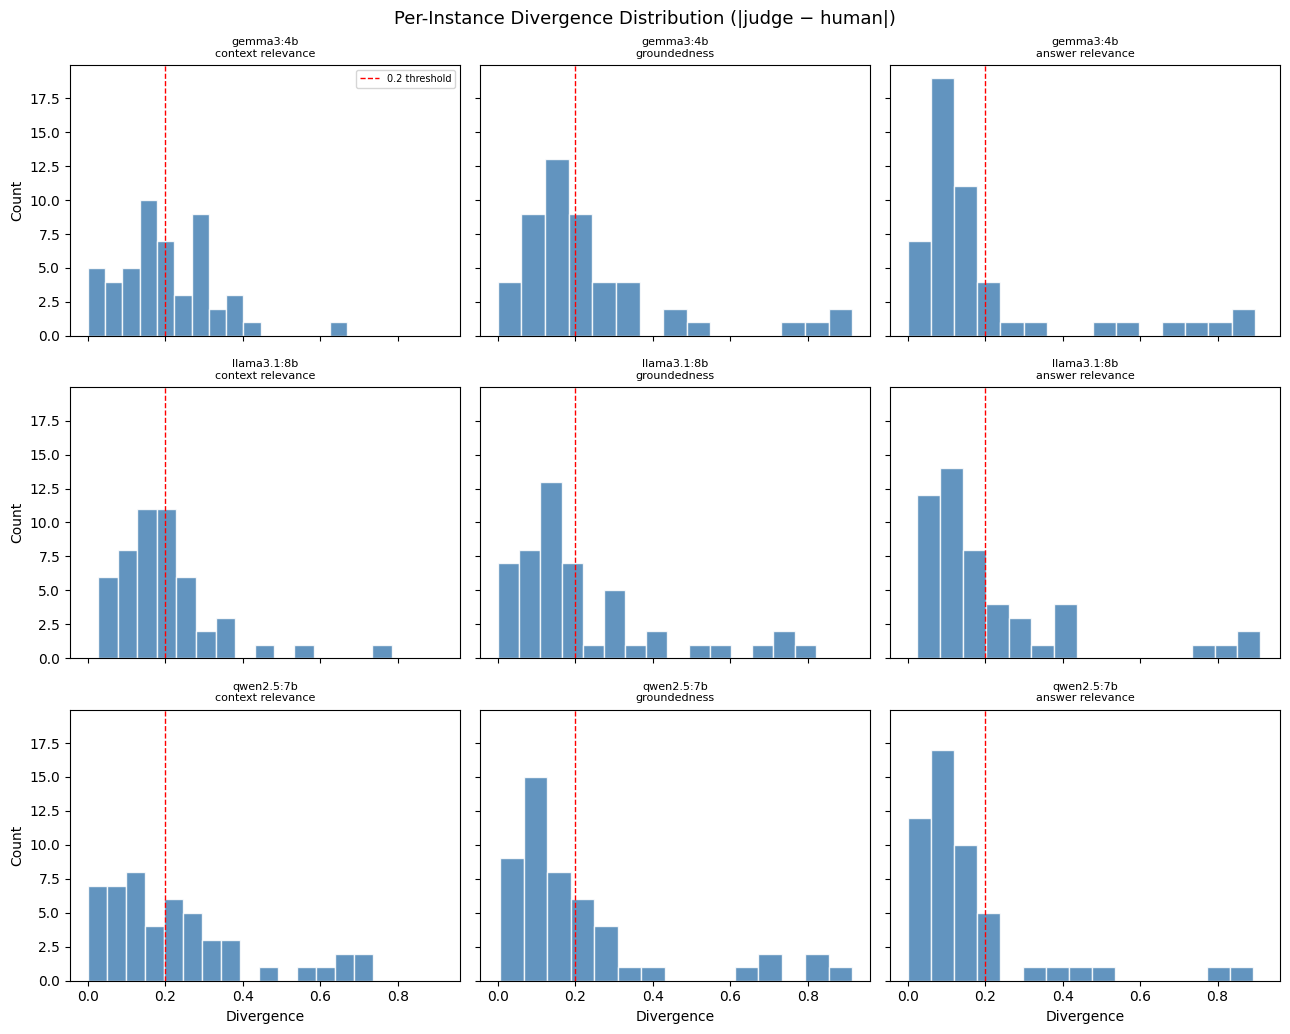

In [5]:
# Divergence distribution — 3×3 grid of histograms (model × metric)
if not div_df.empty:
    available_models = [m for m in MODELS if m in div_df["model"].unique()]
    n_models  = len(available_models)
    n_metrics = len(METRICS)

    fig, axes = plt.subplots(n_models, n_metrics, figsize=(13, 3.5 * n_models), sharex=True, sharey=True)
    if n_models == 1:
        axes = axes[np.newaxis, :]

    for row_idx, model in enumerate(available_models):
        for col_idx, metric in enumerate(METRICS):
            ax = axes[row_idx][col_idx]
            subset = div_df[(div_df["model"] == model) & (div_df["metric"] == metric)]["divergence"]
            ax.hist(subset, bins=15, color="steelblue", edgecolor="white", alpha=0.85)
            ax.axvline(0.2, color="red", linestyle="--", linewidth=1, label="0.2 threshold")
            ax.set_title(f"{model}\n{metric.replace('_', ' ')}", fontsize=8)
            ax.set_xlabel("Divergence" if row_idx == n_models - 1 else "")
            ax.set_ylabel("Count" if col_idx == 0 else "")
            if row_idx == 0 and col_idx == 0:
                ax.legend(fontsize=7)

    fig.suptitle("Per-Instance Divergence Distribution (|judge − human|)", fontsize=13)
    fig.savefig(FIGURES_DIR / "04_divergence_histograms.png", dpi=150, bbox_inches="tight")
    plt.tight_layout()
    plt.show()
else:
    print("No divergence data to plot.")

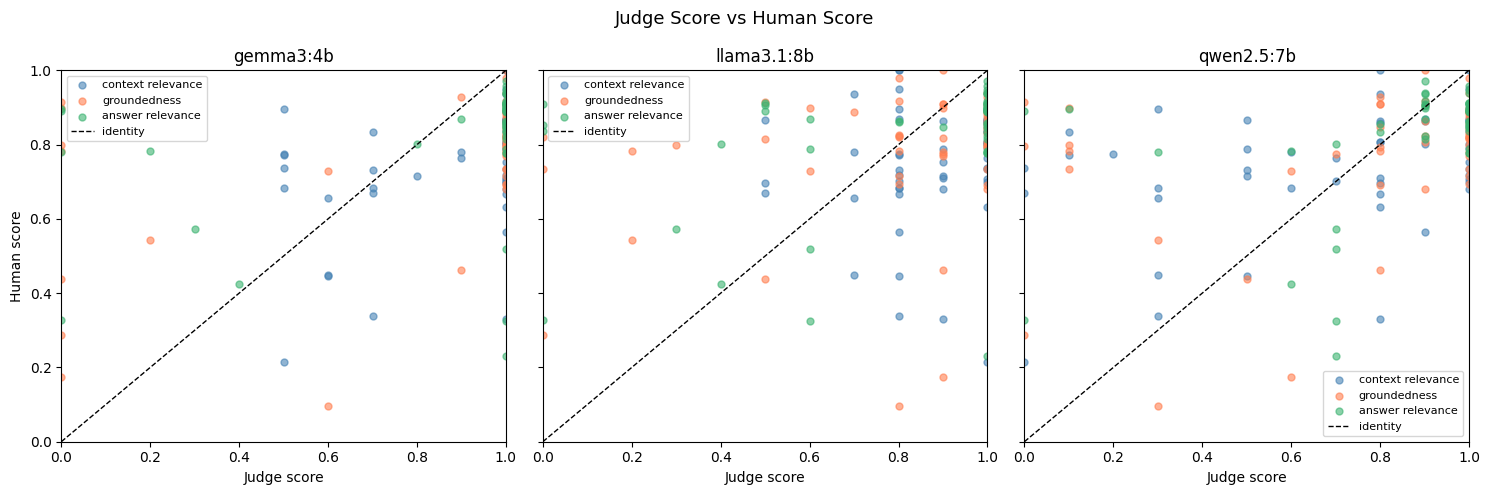

In [6]:
# Scatter plots: judge_score vs human_score with identity line — one panel per model
if "human" in scores:
    available_models = [m for m in MODELS if m in scores]
    metric_colors = {"context_relevance": "steelblue", "groundedness": "coral", "answer_relevance": "mediumseagreen"}

    fig, axes = plt.subplots(1, len(available_models), figsize=(5 * len(available_models), 5), sharey=True)
    if len(available_models) == 1:
        axes = [axes]

    for ax, model in zip(axes, available_models):
        for metric in METRICS:
            if metric not in scores[model] or metric not in scores["human"]:
                continue
            j = scores[model][metric]
            h = scores["human"][metric]
            min_len = min(len(j), len(h))
            ax.scatter(j[:min_len], h[:min_len], s=25, alpha=0.6,
                       color=metric_colors[metric], label=metric.replace("_", " "))
        ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="identity")
        ax.set_xlabel("Judge score")
        ax.set_ylabel("Human score" if ax == axes[0] else "")
        ax.set_title(model)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.legend(fontsize=8)

    fig.suptitle("Judge Score vs Human Score", fontsize=13)
    fig.savefig(FIGURES_DIR / "04_judge_vs_human_scatter.png", dpi=150, bbox_inches="tight")
    plt.tight_layout()
    plt.show()
else:
    print("No human scores available for scatter plot.")

In [7]:
# Absence-reasoning analysis
if not answers_df.empty and "question_type" in answers_df.columns:
    absence_ids = set(answers_df[answers_df["question_type"] == "absence_reasoning"]["id"].astype(str))
    print(f"Found {len(absence_ids)} absence-reasoning instances: {sorted(absence_ids)[:10]}")

    if absence_ids and not div_df.empty:
        absence_div = div_df[div_df["id"].astype(str).isin(absence_ids)]
        other_div   = div_df[~div_df["id"].astype(str).isin(absence_ids)]

        print("\nMean judge vs human scores — absence_reasoning instances:")
        print(f"  {'model':20s}  {'metric':25s}  {'mean_judge':>10s}  {'mean_human':>10s}  {'mean_div':>10s}")
        print("-" * 85)
        for model in [m for m in MODELS if m in div_df["model"].unique()]:
            for metric in METRICS:
                sub = absence_div[(absence_div["model"] == model) & (absence_div["metric"] == metric)]
                if sub.empty:
                    continue
                mj = sub["judge_score"].mean()
                mh = sub["human_score"].mean()
                md = sub["divergence"].mean()
                print(f"  {model:20s}  {metric:25s}  {mj:10.4f}  {mh:10.4f}  {md:10.4f}")
    else:
        print("  No absence-reasoning instances found in divergence data.")
else:
    print("No answer corpus with question_type available — skipping absence-reasoning analysis.")

Found 13 absence-reasoning instances: ['hc03_bad', 'hc03_good', 'hc03_mediocre', 'q03_graph', 'q03_vector', 'q07_graph', 'q07_vector', 'q14_graph', 'q14_vector', 'q17_graph']

Mean judge vs human scores — absence_reasoning instances:
  model                 metric                     mean_judge  mean_human    mean_div
-------------------------------------------------------------------------------------
  gemma3:4b             context_relevance              0.6154      0.6874      0.1716
  gemma3:4b             groundedness                   0.5000      0.7331      0.4077
  gemma3:4b             answer_relevance               0.6308      0.7873      0.3701
  llama3.1:8b           context_relevance              0.8000      0.6874      0.1534
  llama3.1:8b           groundedness                   0.6615      0.7331      0.3376
  llama3.1:8b           answer_relevance               0.6769      0.7873      0.3637
  qwen2.5:7b            context_relevance              0.2692      0.6874     

In [8]:
# Failure mode summary report
if not div_df.empty:
    mean_div_by_model = div_df.groupby("model")["divergence"].mean()
    worst_model = mean_div_by_model.idxmax()

    mean_div_by_metric = div_df.groupby("metric")["divergence"].mean()
    worst_metric = mean_div_by_metric.idxmax()

    signed_div = div_df["judge_score"] - div_df["human_score"]
    inflation_rate = (signed_div > 0).mean() * 100
    large_disagreement_rate = (div_df["divergence"] > 0.2).mean() * 100

    print("=" * 60)
    print("FAILURE MODE SUMMARY")
    print("=" * 60)
    print(f"  Model with highest mean divergence : {worst_model}")
    print(f"    Mean divergence: {mean_div_by_model[worst_model]:.4f}")
    print()
    print(f"  Metric with highest mean divergence: {worst_metric}")
    print(f"    Mean divergence: {mean_div_by_metric[worst_metric]:.4f}")
    print()
    print(f"  Score inflation rate (judge > human): {inflation_rate:.1f}%")
    print(f"  Large disagreement rate (div > 0.2) : {large_disagreement_rate:.1f}%")
    print()
    print("  Mean divergence by model:")
    for model, div in mean_div_by_model.sort_values(ascending=False).items():
        print(f"    {model:20s}: {div:.4f}")
    print()
    print("  Mean divergence by metric:")
    for metric, div in mean_div_by_metric.sort_values(ascending=False).items():
        print(f"    {metric:25s}: {div:.4f}")
    print("=" * 60)
else:
    print("No divergence data available — run after scoring all answers.")

if not div_df.empty:
    available_models_local = [m for m in MODELS if m in div_df["model"].unique()]
    failure_summary = {"models": {}}
    for model in available_models_local:
        model_rows = div_df[div_df["model"] == model]
        if not model_rows.empty:
            failure_summary["models"][model] = {
                "mean_divergence": round(float(model_rows["divergence"].mean()), 4),
                "inflation_rate": round(float((model_rows["judge_score"] > model_rows["human_score"]).mean()), 4),
                "large_disagreement_rate": round(float((model_rows["divergence"] > 0.2).mean()), 4),
            }
    failure_path = RESULTS_DIR / "04_failure_summary.json"
    failure_path.write_text(json.dumps(failure_summary, indent=2))
    print(f"Saved failure summary to {failure_path}")

FAILURE MODE SUMMARY
  Model with highest mean divergence : gemma3:4b
    Mean divergence: 0.2156

  Metric with highest mean divergence: groundedness
    Mean divergence: 0.2265

  Score inflation rate (judge > human): 71.3%
  Large disagreement rate (div > 0.2) : 34.2%

  Mean divergence by model:
    gemma3:4b           : 0.2156
    llama3.1:8b         : 0.2073
    qwen2.5:7b          : 0.2009

  Mean divergence by metric:
    groundedness             : 0.2265
    context_relevance        : 0.2082
    answer_relevance         : 0.1891
Saved failure summary to /workspaces/llm_judge_benchmark/outputs/results/04_failure_summary.json


Proceed to notebook **05** for calibration and correction.